In [1]:
import torchvision as tv
import torchvision.transforms as tvt
import torch as t

In [2]:
import numpy as np
import cv2


base_dir = "/home/ktokarski/DALI_extra/db/single/jpeg/"
paths = [
    "704/parking-meter-3556171_960_720.jpg",
    "362/badger-44204_1280.jpg",
    "100/swan-3584559_640.jpg",
    "312/cricket-1345065_1280.jpg",
    "134/harbour-crane-1643476_1280.jpg",
    "814/speedboat-271768_960_720.jpg",
]
imgs = [
    cv2.imread("".join([base_dir, path]))
    for path in paths
]
imgs = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in imgs]
# pimgs = [Image.fromarray(img) for img in imgs]
nimgs = [np.array(img) for img in imgs]
timgs = [t.tensor(img.transpose(2, 0, 1)) for img in nimgs]

In [3]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def display_imgs(outputs, columns=2, captions=None, cpu=True):
    rows = (len(outputs) + columns - 1) // columns
    fig = plt.figure()
    fig.set_size_inches(16, 6 * rows)
    gs = gridspec.GridSpec(rows, columns)
    row = 0
    col = 0
    for i in range(len(outputs)):
        plt.subplot(gs[i])
        plt.axis("off")
        if captions is not None:
            plt.title(captions[i])
        if hasattr(outputs, 'at'):
            out = outputs.at(i) if cpu else outputs.as_cpu().at(i)
        else:
            out = outputs[i]
        if len(out.shape) == 2 or (len(out.shape) == 3 and out.shape[-1] == 1):
            plt.imshow(out, cmap='gray')
        else:
            plt.imshow(out)

In [12]:
ra = tvt.RandAugment(1, 29)

In [13]:
ra_imgs = [ra(timgs[0]) for _ in range(32)]

In [14]:
n_ra_imgs = [np.array(img).transpose(1, 2, 0) for img in ra_imgs]

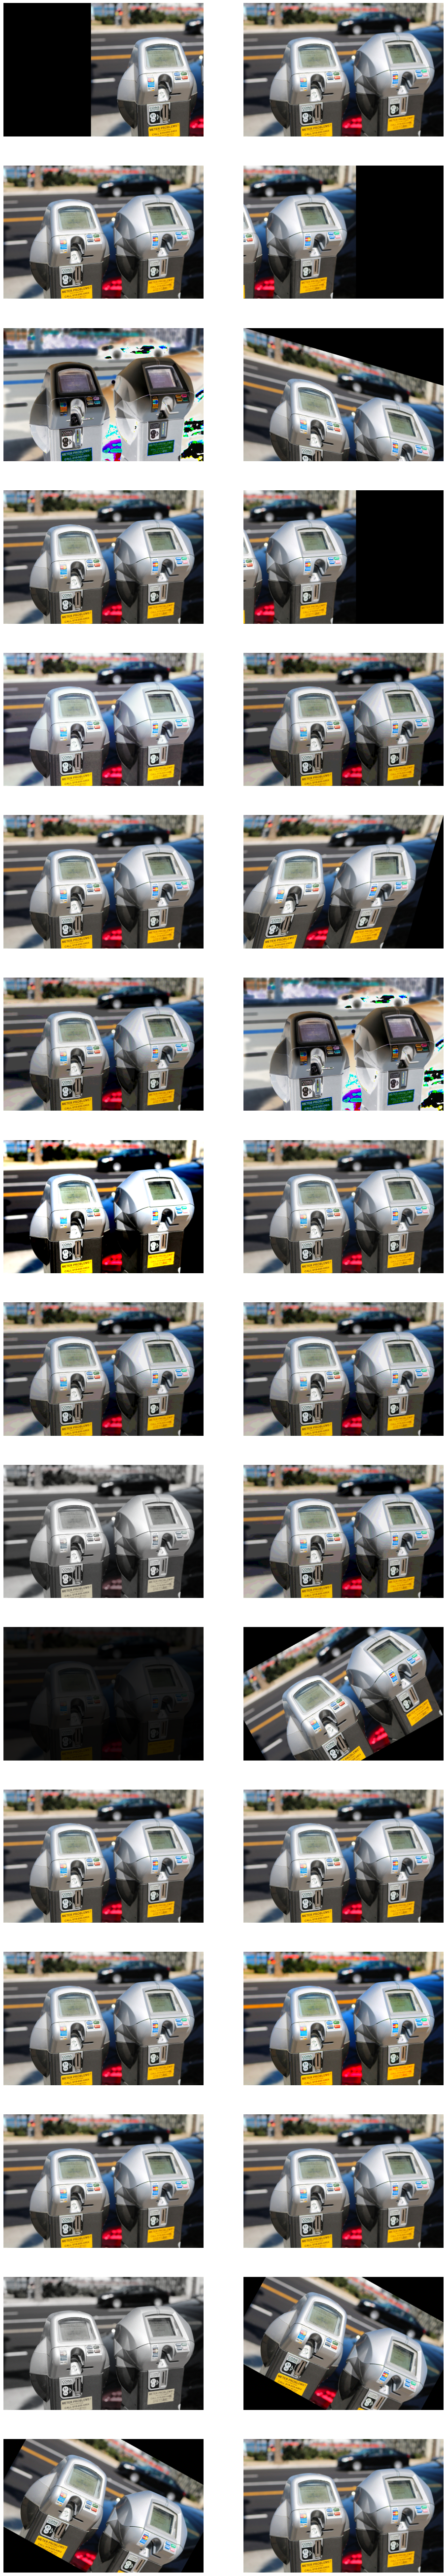

In [15]:
display_imgs(n_ra_imgs)